In [1]:
!python main.py -m DeepCNN --layers 8 pool 16 pool 32 pool 64 pool --transform aug --epoch 100 --batch-size 16

DeepCNN(
  (conv): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=9216, out_features=2, bias=True)
)
There are 42962 parameters in this model
Use aug transformer for training

Epoch 1 / 100
train Accuracy: 0.6901172529313233
valid Accuracy: 0.6933333333333334
  ✓ Validation accuracy improved: 0.0000 → 0.6933 (saving model)

Epoch 2 / 100
train Accuracy: 0.72864321608


100%|██████████| 38/38 [00:10<00:00,  3.65it/s]

100%|██████████| 5/5 [00:00<00:00,  6.92it/s]

100%|██████████| 38/38 [00:10<00:00,  3.70it/s]

100%|██████████| 5/5 [00:01<00:00,  4.94it/s]

100%|██████████| 38/38 [00:14<00:00,  2.68it/s]

100%|██████████| 5/5 [00:01<00:00,  4.39it/s]

100%|██████████| 38/38 [00:12<00:00,  2.93it/s]

100%|██████████| 5/5 [00:00<00:00,  8.49it/s]

100%|██████████| 38/38 [00:07<00:00,  4.89it/s]

100%|██████████| 5/5 [00:00<00:00,  8.59it/s]

100%|██████████| 38/38 [00:07<00:00,  4.91it/s]

100%|██████████| 5/5 [00:00<00:00,  8.67it/s]

100%|██████████| 38/38 [00:06<00:00,  5.52it/s]

100%|██████████| 5/5 [00:00<00:00,  8.63it/s]

100%|██████████| 38/38 [00:07<00:00,  5.06it/s]

100%|██████████| 5/5 [00:00<00:00,  8.88it/s]

100%|██████████| 38/38 [00:06<00:00,  5.63it/s]

100%|██████████| 5/5 [00:00<00:00,  8.52it/s]

100%|██████████| 38/38 [00:07<00:00,  4.82it/s]

100%|██████████| 5/5 [00:00<00:00,  8.75it/s]

100%|██████████| 38/38 [00:07<00:00,  5

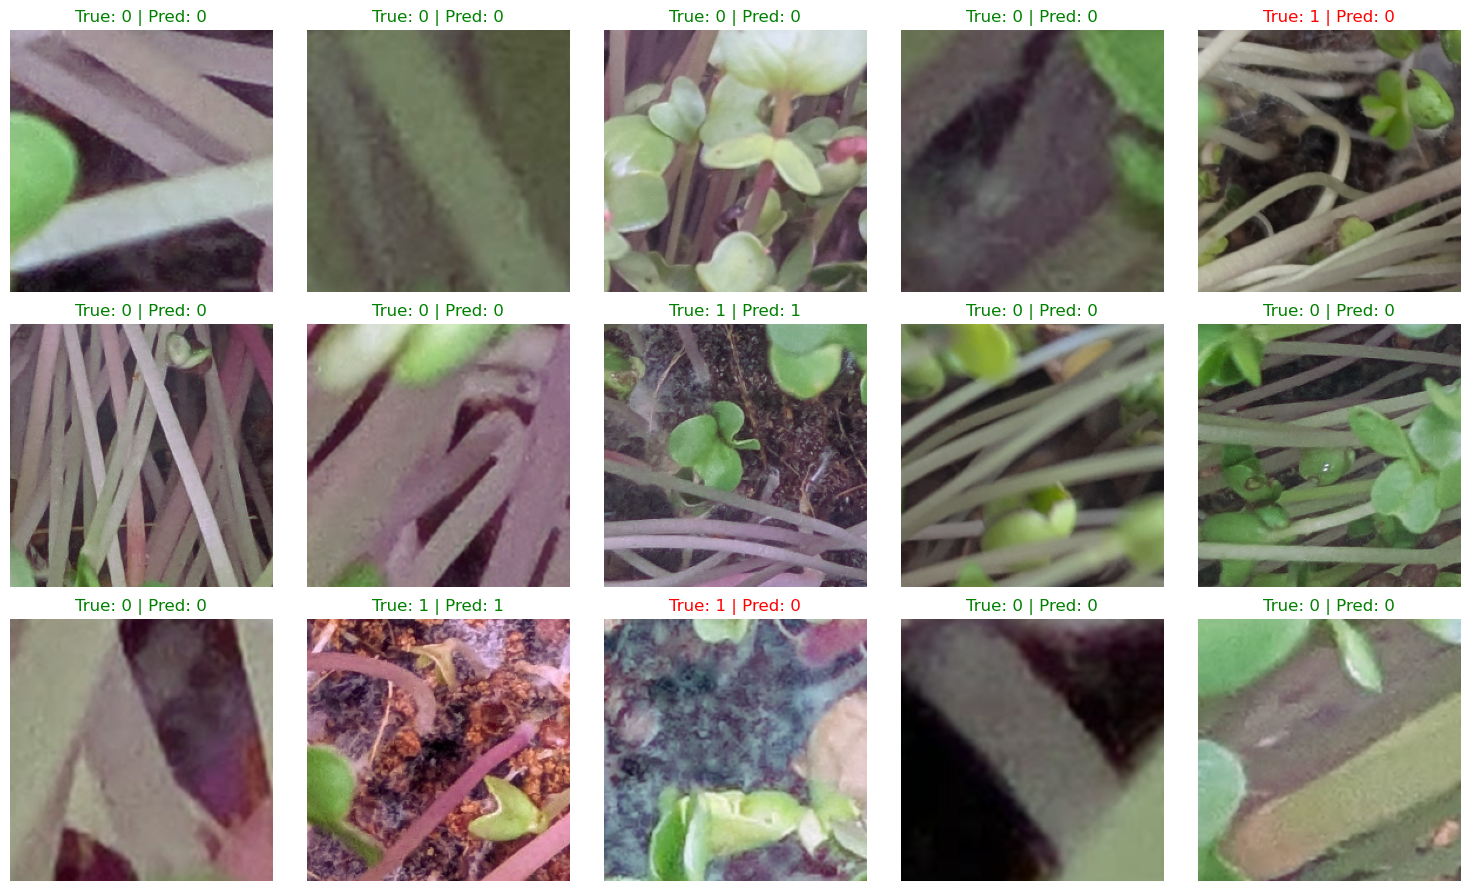

In [2]:
import torch
from model import DeepCNN, norm_transformer
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import os 

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

# Load SimpleCNN model
net = DeepCNN(arr=[8, "pool", 16, "pool", 32, "pool", 64, "pool"])
net.load_state_dict(torch.load("best_DeepCNN.pt"))
net.eval()
if use_cuda:
    net = net.to(device)

# Load test CSV
test_df = pd.read_csv("test.csv")

# Randomly pick 15 images
samples = test_df.sample(n=15, random_state=12).reset_index(drop=True)

# Plot 15 images
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i, row in samples.iterrows():
    img = Image.open(row["path"])

    input_tensor = norm_transformer(img).unsqueeze(0)
    if use_cuda:
        input_tensor = input_tensor.to(device)

    with torch.no_grad():
        output = net(input_tensor)
        _, pred = torch.max(output, 1)

    axes[i].imshow(img)
    color = 'green' if pred.item() == row["label"] else 'red'
    axes[i].set_title(f"True: {row['label']} | Pred: {pred.item()}", color=color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()
